<a href="https://colab.research.google.com/github/gustavo159753/Machine-learning-and-AI/blob/main/luminancia_rgb_gray.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Ok. Para fazermos "na mão" precisamos entender como a mudança de RGB para escalas de cinza funciona. Para isso, utilizei um artigo (link: https://www.itu.int/dms_pubrec/itu-r/rec/bt/r-rec-bt.601-7-201103-i!!pdf-e.pdf) que mostra como é a formula para trazer uma imagem colorida para escala de cinza. A fórmula é:
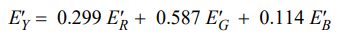

#Com isso, é possível aplicar essa equação na matriz da imagem e converte-la em escala de cinza. Simples, certo? nem tanto, porém eu sou engenheiro e estou aqui para resolver problemas!

Neste caso eu apenas importei essas bibliotecas para trabalhar a imagem como matriz. Nada de mais...

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
from google.colab import files

In [ ]:
# 1. FAZ O UPLOAD PRIMEIRO
uploaded = files.upload()

# Pega o nome do arquivo que acabamos de subir
nome_do_arquivo = list(uploaded.keys())[0]

Saving 037e3a54-35b1-4622-9bbb-fe50f92d4ece.jpg to 037e3a54-35b1-4622-9bbb-fe50f92d4ece (1).jpg


In [ ]:
def processar_imagem(caminho_imagem, threshold=127):

    # Agora o imread recebe apenas o nome do arquivo
    img = mpimg.imread(caminho_imagem)

    # Se for PNG, o Matplotlib lê como float (0-1).
    # Se for JPG, lê como int (0-255). Vamos normalizar para 0-255:
    if img.max() <= 1.0:
        img = (img * 255).astype(np.uint8)

    if img.shape[2] == 4:
        img = img[:, :, :3]

    altura, largura, _ = img.shape
    img_cinza = np.zeros((altura, largura), dtype=np.uint8)

    # Conversão para Cinza
    for i in range(altura):
        for j in range(largura):
            r, g, b = img[i, j]
            # Usando a fórmula de luminância
            valor_cinza = int(r*0.299 + g*0.587 + b*0.114)
            img_cinza[i, j] = valor_cinza

    # Binarização
    img_binaria = np.zeros((altura, largura), dtype=np.uint8)
    for i in range(altura):
        for j in range(largura):
            if img_cinza[i, j] > threshold:
                img_binaria[i, j] = 255
            else:
                img_binaria[i, j] = 0

    return img, img_cinza, img_binaria

# 2. EXECUÇÃO
# Passamos o nome do arquivo que pegamos lá em cima
original, cinza, binaria = processar_imagem(nome_do_arquivo)

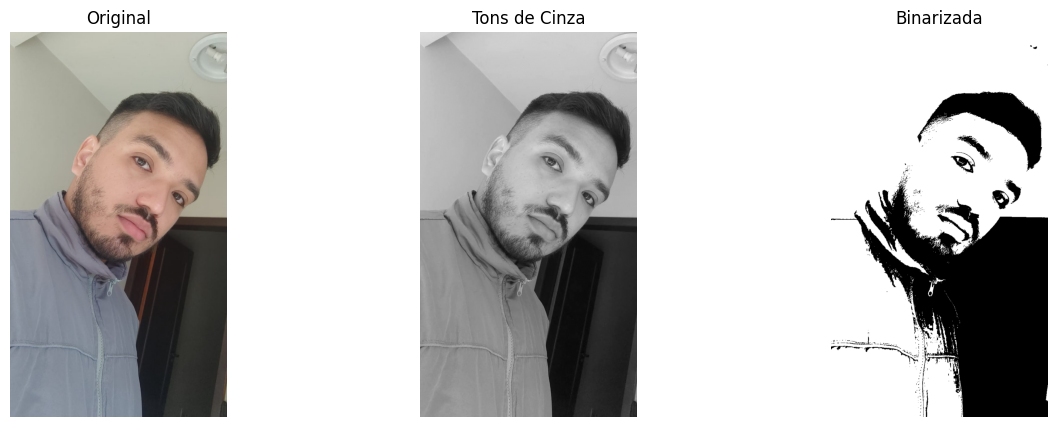

In [ ]:
# Visualização
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(original)
axes[0].set_title("Original")
axes[1].imshow(cinza, cmap='gray')
axes[1].set_title("Tons de Cinza")
axes[2].imshow(binaria, cmap='gray')
axes[2].set_title("Binarizada")

for ax in axes: ax.axis('off')
plt.show()